In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [2]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_moons

X,y = make_moons(n_samples= 300 , noise = 0.1)


In [3]:
X

array([[-4.53631737e-01,  7.99308582e-01],
       [-4.42133856e-01,  9.26114239e-01],
       [-5.34851539e-01,  9.65181028e-01],
       [ 1.61656841e+00, -4.17370334e-02],
       [-5.24128986e-01,  9.01055548e-01],
       [ 3.46901350e-01,  8.82045784e-01],
       [ 7.86651037e-02,  1.02572442e+00],
       [ 1.17084583e-01, -7.95828364e-02],
       [ 4.94155557e-01,  7.18759695e-01],
       [ 1.13107915e+00, -3.47321537e-01],
       [ 1.77028737e+00, -6.97296073e-02],
       [-1.15903320e+00,  1.09642073e-01],
       [ 9.68048300e-01, -5.69591167e-01],
       [ 8.54985468e-01,  6.20205562e-01],
       [-2.00420681e-01,  9.83013409e-01],
       [ 1.08485172e+00,  1.64769828e-01],
       [ 1.73324335e+00, -1.01313137e-01],
       [ 9.89706405e-01,  5.80917505e-02],
       [ 2.01456238e+00, -2.16646761e-01],
       [ 5.08598916e-01,  9.27897606e-01],
       [ 1.52082882e+00, -4.33894061e-01],
       [ 1.11975534e+00, -4.97095242e-01],
       [ 6.85362081e-02, -1.70870504e-01],
       [ 1.

In [4]:
y

array([0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0])

In [6]:
X_outliers = np.random.uniform(low=-3,high = 3,  size = (20,2))
X = np.vstack((X ,X_outliers))
X

array([[-4.53631737e-01,  7.99308582e-01],
       [-4.42133856e-01,  9.26114239e-01],
       [-5.34851539e-01,  9.65181028e-01],
       [ 1.61656841e+00, -4.17370334e-02],
       [-5.24128986e-01,  9.01055548e-01],
       [ 3.46901350e-01,  8.82045784e-01],
       [ 7.86651037e-02,  1.02572442e+00],
       [ 1.17084583e-01, -7.95828364e-02],
       [ 4.94155557e-01,  7.18759695e-01],
       [ 1.13107915e+00, -3.47321537e-01],
       [ 1.77028737e+00, -6.97296073e-02],
       [-1.15903320e+00,  1.09642073e-01],
       [ 9.68048300e-01, -5.69591167e-01],
       [ 8.54985468e-01,  6.20205562e-01],
       [-2.00420681e-01,  9.83013409e-01],
       [ 1.08485172e+00,  1.64769828e-01],
       [ 1.73324335e+00, -1.01313137e-01],
       [ 9.89706405e-01,  5.80917505e-02],
       [ 2.01456238e+00, -2.16646761e-01],
       [ 5.08598916e-01,  9.27897606e-01],
       [ 1.52082882e+00, -4.33894061e-01],
       [ 1.11975534e+00, -4.97095242e-01],
       [ 6.85362081e-02, -1.70870504e-01],
       [ 1.

In [7]:
Out = LocalOutlierFactor(n_neighbors=20 , contamination= 0.1)
Out

LocalOutlierFactor(contamination=0.1)

In [9]:
Out.fit(X)

LocalOutlierFactor(contamination=0.1)

In [13]:
y_pred = Out.fit_predict(X)

y_pred

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1, -1

In [14]:
X_inliers = X[y_pred == 1]
X_outliers = X[y_pred == -1]

In [15]:
X_inliers

array([[-4.53631737e-01,  7.99308582e-01],
       [-4.42133856e-01,  9.26114239e-01],
       [-5.34851539e-01,  9.65181028e-01],
       [ 1.61656841e+00, -4.17370334e-02],
       [-5.24128986e-01,  9.01055548e-01],
       [ 3.46901350e-01,  8.82045784e-01],
       [ 7.86651037e-02,  1.02572442e+00],
       [ 1.17084583e-01, -7.95828364e-02],
       [ 4.94155557e-01,  7.18759695e-01],
       [ 1.13107915e+00, -3.47321537e-01],
       [ 1.77028737e+00, -6.97296073e-02],
       [ 9.68048300e-01, -5.69591167e-01],
       [ 8.54985468e-01,  6.20205562e-01],
       [-2.00420681e-01,  9.83013409e-01],
       [ 1.08485172e+00,  1.64769828e-01],
       [ 1.73324335e+00, -1.01313137e-01],
       [ 9.89706405e-01,  5.80917505e-02],
       [ 2.01456238e+00, -2.16646761e-01],
       [ 5.08598916e-01,  9.27897606e-01],
       [ 1.52082882e+00, -4.33894061e-01],
       [ 1.11975534e+00, -4.97095242e-01],
       [ 6.85362081e-02, -1.70870504e-01],
       [ 1.21850329e+00, -5.68053776e-01],
       [ 1.

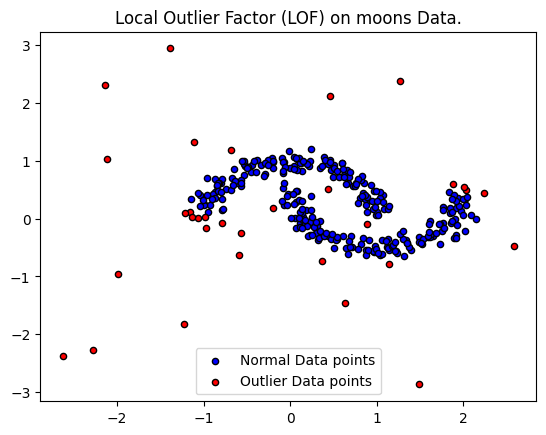

In [18]:
plt.title("Local Outlier Factor (LOF) on moons Data.")
plt.scatter(X_inliers[:, 0], X_inliers[:,1], color = 'b' , s=20 ,edgecolor = 'k', label = 'Normal Data points')
plt.scatter(X_outliers[:, 0], X_outliers[:,1], color = 'r', s=20 ,edgecolor = 'k', label = 'Outlier Data points')
plt.legend()
plt.show()